# Modelo Proyecto 2 

#### Importo las librerías necesarias 

In [50]:
import numpy as np
import pandas as pd
import tensorflow as tf
import mlflow.tensorflow
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


#### Importo los datos 

In [51]:
df = pd.read_csv("Clean_data.csv")

print(df.head)
print(df.shape)

<bound method NDFrame.head of        periodo estu_tipodocumento  estu_consecutivo cole_area_ubicacion  \
0        20181                 CC  SB11201810003214              URBANO   
1        20181                 CC  SB11201810003214              URBANO   
2        20181                 TI  SB11201810043861               RURAL   
3        20181                 TI  SB11201810043861               RURAL   
4        20181                 CC  SB11201810004937               RURAL   
...        ...                ...               ...                 ...   
32338    20181                 TI  SB11201810001140              URBANO   
32339    20181                 TI  SB11201810024724              URBANO   
32340    20181                 TI  SB11201810024724              URBANO   
32341    20181                 TI  SB11201810019065              URBANO   
32342    20181                 TI  SB11201810019065              URBANO   

      cole_bilingue cole_calendario cole_caracter  \
0               

#### Identifico los NAs en los datos  y revisamos el tipo de datos

In [52]:
df.isna().sum()
df.dropna(inplace=True)
df.dtypes

periodo                            int64
estu_tipodocumento                object
estu_consecutivo                  object
cole_area_ubicacion               object
cole_bilingue                     object
cole_calendario                   object
cole_caracter                     object
cole_cod_dane_establecimiento      int64
cole_cod_dane_sede                 int64
cole_cod_depto_ubicacion           int64
cole_cod_mcpio_ubicacion           int64
cole_codigo_icfes                  int64
cole_depto_ubicacion              object
cole_genero                       object
cole_jornada                      object
cole_mcpio_ubicacion              object
cole_naturaleza                   object
cole_nombre_establecimiento       object
cole_nombre_sede                  object
cole_sede_principal               object
estu_cod_depto_presentacion      float64
estu_cod_mcpio_presentacion      float64
estu_cod_reside_depto            float64
estu_cod_reside_mcpio            float64
estu_depto_prese

### Definimos listas para las variables categóricas enteras, categóricas string y numéricas.

In [53]:
#Seleccionar solo las variables socio demograficas y de entorno educativo 

variables_sociodemograficas = [
    'cole_area_ubicacion', 'cole_bilingue', 'cole_calendario', 'cole_caracter',
    'cole_genero', 'cole_jornada', 'cole_naturaleza', 'cole_depto_ubicacion', 'cole_mcpio_ubicacion',
    'estu_tipodocumento', 'estu_genero', 'estu_depto_reside', 'estu_mcpio_reside',
    'estu_nacionalidad', 'estu_pais_reside', 'estu_privado_libertad',
    'fami_cuartoshogar', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_estratovivienda',
    'fami_personashogar', 'fami_tieneautomovil', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_tienelavadora'
]

### Calculo el promedio nacional del promedio global

In [54]:
promedio_nacional = df['punt_global'].mean()
print(f"Promedio nacional de puntaje global: {promedio_nacional:.2f}")

Promedio nacional de puntaje global: 300.21


#### Creo columna de desempeño (0 =Bajo, 1 = Medio, 2 = Alto)

In [55]:
def clasificar_desempeno(puntaje):
    if puntaje < promedio_nacional * 0.9:
        return 0  # bajo
    elif puntaje < promedio_nacional * 1.1:
        return 1  # medio
    else:
        return 2  # alto

df['desempeno'] = df['punt_global'].apply(clasificar_desempeno)

### Convertir la variables categoricas a dummies 

### Uno las númericas con las dummies 

In [56]:
X = pd.get_dummies(df[variables_sociodemograficas])
y = df['desempeno']

### Entreno el modelo

In [57]:
# Tomamos el 80% para entrenamiento
train = X.sample(frac=0.8, random_state=100)
# El resto será test
test = X.drop(train.index)

# De train, sacamos el 20% para validación
val = train.sample(frac=0.2, random_state=100)
# Actualizamos train quitando las filas que se fueron a validación
train = train.drop(val.index)

# Separar etiquetas
y_train = y[train.index]
y_val = y[val.index]
y_test = y[test.index]

# Confirmar tamaños
print("Train:", train.shape, "Validation:", val.shape, "Test:", test.shape)

# Guardar las columnas usadas para entrenar el modelo
np.save("columnas_modelo.npy", train.columns.to_numpy())

Train: (20603, 585) Validation: (5151, 585) Test: (6438, 585)


### Modelo 

In [58]:
# Configurar experimento en MLflow
mlflow.set_experiment('Experimento con capas')
mlflow.tensorflow.autolog()

## Modelo1: con dos capas ocultas y 32 neuronas en cada capa, 3 de salida  

2025/05/25 20:20:30 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 20:20:30 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6079 - loss: 0.8381

644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6080 - loss: 0.8380 - val_accuracy: 0.6469 - val_loss: 0.7657
Epoch 2/20
640/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6365 - loss: 0.7656

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6365 - loss: 0.7655 - val_accuracy: 0.6459 - val_loss: 0.7610
Epoch 3/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6521 - loss: 0.7453 - val_accuracy: 0.6476 - val_loss: 0.7622
Epoch 4/20
626/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6578 - loss: 0.7375

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6577 - loss: 0.7375 - val_accuracy: 0.6504 - val_loss: 0.7590
Epoch 5/20
625/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6609 - loss: 0.7250

644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6608 - loss: 0.7251 - val_accuracy: 0.6449 - val_loss: 0.7556
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6660 - loss: 0.7254 - val_accuracy: 0.6539 - val_loss: 0.7576
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6731 - loss: 0.7109 - val_accuracy: 0.6484 - val_loss: 0.7596
Epoch 8/20
636/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6783 - loss: 0.7014

644/644 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6783 - loss: 0.7014 - val_accuracy: 0.6593 - val_loss: 0.7548
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6856 - loss: 0.6867 - val_accuracy: 0.6525 - val_loss: 0.7620
Epoch 10/20
627/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6832 - loss: 0.6850

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6833 - loss: 0.6850 - val_accuracy: 0.6605 - val_loss: 0.7530
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6918 - loss: 0.6724 - val_accuracy: 0.6564 - val_loss: 0.7542
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6966 - loss: 0.6713 - val_accuracy: 0.6585 - val_loss: 0.7626
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7074 - loss: 0.6523 - val_accuracy: 0.6537 - val_loss: 0.7654
Epoch 14/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7063 - loss: 0.6516 - val_accuracy: 0.6624 - val_loss: 0.7595
Epoch 15/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7095 - loss: 0.6413 - val_accuracy: 0.6599 - val_loss: 0.7748
Epoch 16/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7137 - loss: 0.6361 - val_accuracy: 0.6606 - val_loss: 0.7667
Epoch 17/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7116 - loss: 0.6391 - val_accuracy: 0.6634

2025/05/25 20:21:10 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 20:21:10 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 20:21:29 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6561 - loss: 0.7796
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Modelo 1 - Accuracy: 0.6508, Loss: 0.7859, MSE: 0.4689, R²: 0.3041


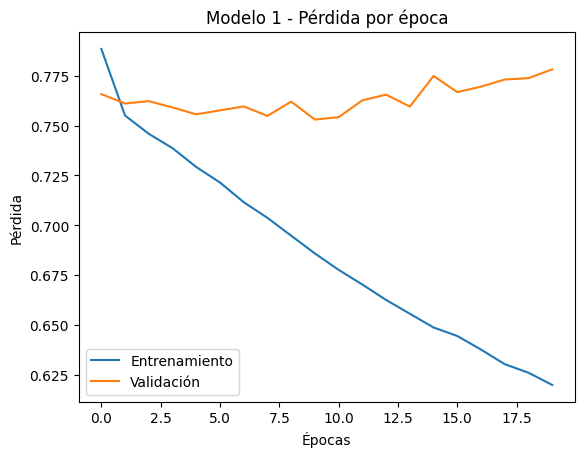

In [47]:
with mlflow.start_run(run_name='Modelo 1'):
    model1 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(32, activation='relu'),   # Primera capa oculta
        layers.Dense(32, activation='relu'),   # Segunda capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida (3 clases)
    ])

    model1.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history1 = model1.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    # Evaluar en test
    test_loss1, test_acc1 = model1.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc1)
    mlflow.log_metric('test_loss', test_loss1)

    # Obtener predicciones (probabilidades)
    predicciones_prob = model1.predict(test)
    # Convertir a clases 0,1,2
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R²
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    # Log de métricas adicionales en MLflow
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("R2", r2)

    print(f"Modelo 1 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    # Gráfica de pérdidas
    plt.plot(history1.history['loss'], label='Entrenamiento')
    plt.plot(history1.history['val_loss'], label='Validación')
    plt.title('Modelo 1 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


## Modelo 2: con tres capas 16 neuronas en cada capa, capa de normalización y tres salidas 

2025/05/25 20:23:43 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 20:23:43 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
618/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5901 - loss: 0.8701

644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5916 - loss: 0.8673 - val_accuracy: 0.6391 - val_loss: 0.7699
Epoch 2/20
642/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6471 - loss: 0.7569

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6470 - loss: 0.7569 - val_accuracy: 0.6441 - val_loss: 0.7618
Epoch 3/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6525 - loss: 0.7473 - val_accuracy: 0.6480 - val_loss: 0.7638
Epoch 4/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6556 - loss: 0.7410 - val_accuracy: 0.6389 - val_loss: 0.7704
Epoch 5/20
621/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6565 - loss: 0.7362

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6564 - loss: 0.7362 - val_accuracy: 0.6486 - val_loss: 0.7548
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6624 - loss: 0.7261 - val_accuracy: 0.6445 - val_loss: 0.7580
Epoch 7/20
633/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6597 - loss: 0.7182

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6598 - loss: 0.7183 - val_accuracy: 0.6513 - val_loss: 0.7538
Epoch 8/20
641/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6681 - loss: 0.7171

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6681 - loss: 0.7171 - val_accuracy: 0.6480 - val_loss: 0.7528
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6773 - loss: 0.7097 - val_accuracy: 0.6527 - val_loss: 0.7608
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6765 - loss: 0.7093 - val_accuracy: 0.6488 - val_loss: 0.7611
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6775 - loss: 0.6997 - val_accuracy: 0.6397 - val_loss: 0.7743
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6833 - loss: 0.6937 - val_accuracy: 0.6564 - val_loss: 0.7564
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6791 - loss: 0.6941 - val_accuracy: 0.6523 - val_loss: 0.7629
Epoch 14/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6843 - loss: 0.6906 - val_accuracy: 0.6509 - val_loss: 0.7620
Epoch 15/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6791 - loss: 0.6889 - val_accuracy: 0.6515 

2025/05/25 20:24:34 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 20:24:34 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 20:24:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6604 - loss: 0.7744
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Modelo 2 - Accuracy: 0.6502, Loss: 0.7777, MSE: 0.4136, R²: 0.3862


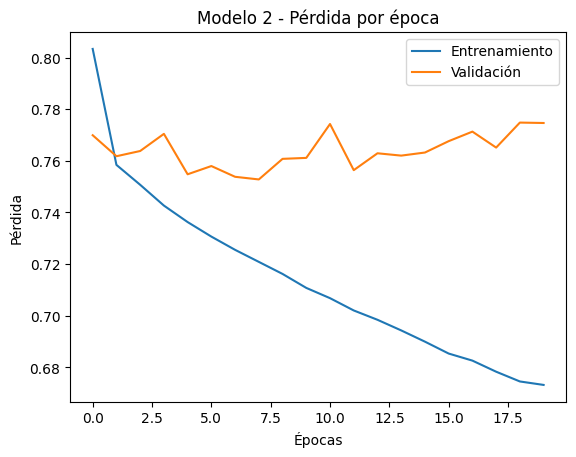

In [48]:
with mlflow.start_run(run_name='Modelo2'):
    model2 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),
        layers.Normalization(),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model2.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history2 = model2.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    # Evaluar en test
    test_loss2, test_acc2 = model2.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc2)
    mlflow.log_metric('test_loss', test_loss2)

    # Obtener predicciones del Modelo 2
    predicciones_prob = model2.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R² del Modelo 2
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("R2", r2)

    print(f"Modelo 2 - Accuracy: {test_acc2:.4f}, Loss: {test_loss2:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    # Gráfica de pérdidas
    plt.plot(history2.history['loss'], label='Entrenamiento')
    plt.plot(history2.history['val_loss'], label='Validación')
    plt.title('Modelo 2 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 3: con 4 capas ocultas y 64 neurnonas en dos capas y 32 neuronas en dos, 3 de salida 

2025/05/25 20:25:10 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 20:25:10 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
642/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6116 - loss: 0.8243

644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6117 - loss: 0.8242 - val_accuracy: 0.6469 - val_loss: 0.7585
Epoch 2/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6504 - loss: 0.7534 - val_accuracy: 0.6471 - val_loss: 0.7591
Epoch 3/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6578 - loss: 0.7346 - val_accuracy: 0.6436 - val_loss: 0.7673
Epoch 4/20
641/644 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6692 - loss: 0.7200

644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6691 - loss: 0.7200 - val_accuracy: 0.6577 - val_loss: 0.7465
Epoch 5/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6784 - loss: 0.6995 - val_accuracy: 0.6523 - val_loss: 0.7555
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6846 - loss: 0.6864 - val_accuracy: 0.6612 - val_loss: 0.7500
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6926 - loss: 0.6736 - val_accuracy: 0.6498 - val_loss: 0.7595
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7071 - loss: 0.6445 - val_accuracy: 0.6482 - val_loss: 0.7686
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7215 - loss: 0.6260 - val_accuracy: 0.6560 - val_loss: 0.7686
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7269 - loss: 0.6072 - val_accuracy: 0.6523 - val_loss: 0.7767
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7417 - loss: 0.5846 - val_accuracy: 0.6661 - v

2025/05/25 20:26:59 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 20:26:59 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 20:27:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6897 - loss: 0.8748
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Modelo 3 - Accuracy: 0.6915, Loss: 0.8655, MSE: 0.4021, R²: 0.4033


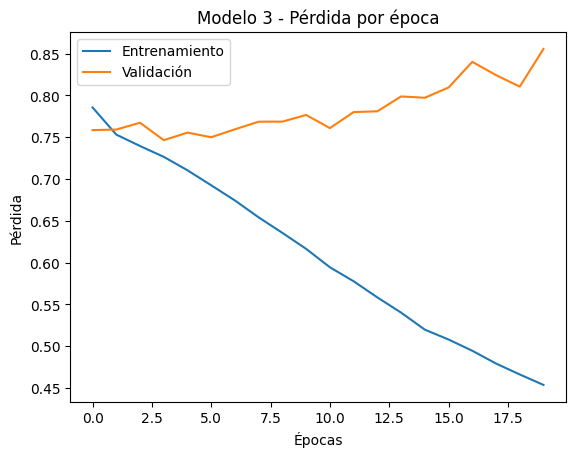

In [49]:
with mlflow.start_run(run_name='Modelo3'):
    model3 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(64, activation='relu'),  # Primera capa oculta
        layers.Dense(64, activation='relu'),   # Segunda capa oculta
        layers.Dense(32, activation='relu'),   # Tercera capa oculta
        layers.Dense(32, activation='relu'),   # Cuarta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model3.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history3 = model3.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss3, test_acc3 = model3.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc3)
    mlflow.log_metric('test_loss', test_loss3)

     # Obtener predicciones del Modelo 3
    predicciones_prob = model3.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)
    
    # Calcular MSE y R²
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    # Log de métricas adicionales en MLflow
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("R2", r2)

    print(f"Modelo 3 - Accuracy: {test_acc3:.4f}, Loss: {test_loss3:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history3.history['loss'], label='Entrenamiento')
    plt.plot(history3.history['val_loss'], label='Validación')
    plt.title('Modelo 3 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 4: con 4 capas ocultas 32 neuronas en cada capa, 1 capa de normalización y tres  de salidad

2025/05/25 20:13:29 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 20:13:29 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
639/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5779 - loss: 0.8587

644/644 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5783 - loss: 0.8582 - val_accuracy: 0.6500 - val_loss: 0.7592
Epoch 2/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6517 - loss: 0.7526 - val_accuracy: 0.6480 - val_loss: 0.7605
Epoch 3/20
642/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6466 - loss: 0.7569

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6466 - loss: 0.7569 - val_accuracy: 0.6486 - val_loss: 0.7563
Epoch 4/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6471 - loss: 0.7476 - val_accuracy: 0.6482 - val_loss: 0.7567
Epoch 5/20
639/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6642 - loss: 0.7282

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6642 - loss: 0.7282 - val_accuracy: 0.6492 - val_loss: 0.7558
Epoch 6/20
633/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6659 - loss: 0.7201

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6658 - loss: 0.7202 - val_accuracy: 0.6465 - val_loss: 0.7531
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6743 - loss: 0.7085 - val_accuracy: 0.6531 - val_loss: 0.7547
Epoch 8/20
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6765 - loss: 0.7071

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6765 - loss: 0.7071 - val_accuracy: 0.6521 - val_loss: 0.7526
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6763 - loss: 0.7012 - val_accuracy: 0.6645 - val_loss: 0.7577
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6885 - loss: 0.6814 - val_accuracy: 0.6527 - val_loss: 0.7552
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6999 - loss: 0.6686 - val_accuracy: 0.6484 - val_loss: 0.7620
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6922 - loss: 0.6668 - val_accuracy: 0.6618 - val_loss: 0.7597
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7088 - loss: 0.6455 - val_accuracy: 0.6585 - val_loss: 0.7589
Epoch 14/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7072 - loss: 0.6484 - val_accuracy: 0.6593 - val_loss: 0.7660
Epoch 15/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7136 - loss: 0.6353 - val_accuracy: 0.6554 

2025/05/25 20:14:24 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 20:14:24 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 20:14:44 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6645 - loss: 0.7944
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


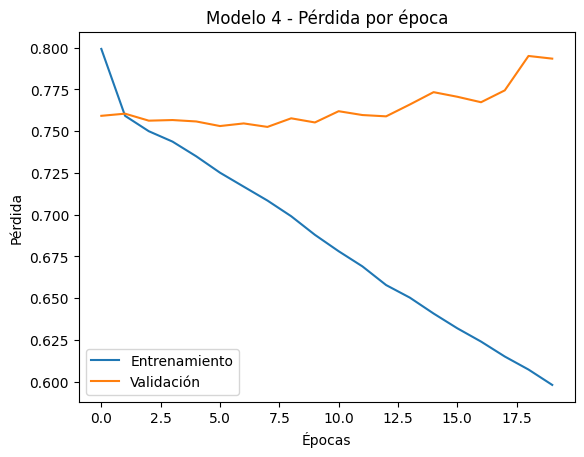

In [ ]:
with mlflow.start_run(run_name='Modelo4'):
    model4 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Normalization(),               # Normalización
        layers.Dense(32, activation='relu'),  # Primera capa oculta
        layers.Dense(32, activation='relu'),  # Segunda capa oculta
        layers.Dense(32, activation='relu'),   # Tercera capa oculta
        layers.Dense(32, activation='relu'),   # Cuarta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model4.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history4 = model4.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss4, test_acc4 = model4.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc4)
    mlflow.log_metric('test_loss', test_loss4)

    # Obtener predicciones del Modelo 4
    predicciones_prob = model4.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R² del Modelo 4
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    print(f"Modelo 4 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history4.history['loss'], label='Entrenamiento')
    plt.plot(history4.history['val_loss'], label='Validación')
    plt.title('Modelo 4 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 5: 5 capas ocultas con variando el número de neuronas de 32 a 256 en cada capa y 3 salidas 

2025/05/25 19:11:32 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 19:11:32 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
642/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5992 - loss: 0.8327

644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5993 - loss: 0.8325 - val_accuracy: 0.6509 - val_loss: 0.7590
Epoch 2/20
629/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6475 - loss: 0.7512

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6475 - loss: 0.7513 - val_accuracy: 0.6531 - val_loss: 0.7508
Epoch 3/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6571 - loss: 0.7331 - val_accuracy: 0.6467 - val_loss: 0.7563
Epoch 4/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6782 - loss: 0.7069 - val_accuracy: 0.6575 - val_loss: 0.7547
Epoch 5/20
633/644 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6875 - loss: 0.6776

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6876 - loss: 0.6776 - val_accuracy: 0.6622 - val_loss: 0.7436
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6991 - loss: 0.6439 - val_accuracy: 0.6583 - val_loss: 0.7481
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7266 - loss: 0.6063 - val_accuracy: 0.6645 - val_loss: 0.7678
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7444 - loss: 0.5697 - val_accuracy: 0.6773 - val_loss: 0.7802
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7779 - loss: 0.5108 - val_accuracy: 0.6764 - val_loss: 0.7990
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7969 - loss: 0.4740 - val_accuracy: 0.7004 - val_loss: 0.7988
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8126 - loss: 0.4368 - val_accuracy: 0.6954 - val_loss: 0.8637
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8343 - loss: 0.3957 - val_accuracy: 0.7055 - v

2025/05/25 19:12:27 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 19:12:27 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 19:12:40 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7395 - loss: 1.1495


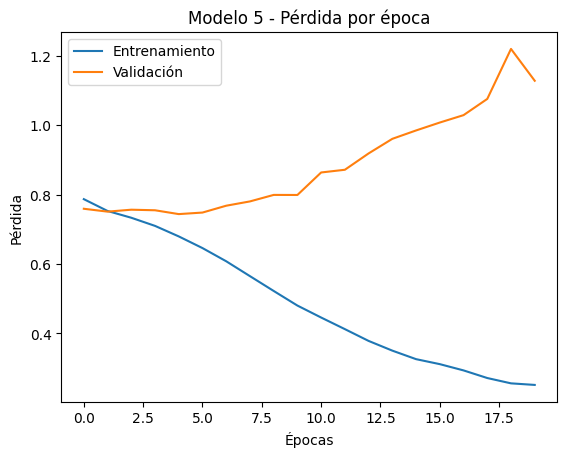

In [ ]:
with mlflow.start_run(run_name='Modelo5_5'):
    model5 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),  # Capa de entrada
        layers.Dense(256, activation='relu'),  # Primera capa oculta
        layers.Dense(128, activation='relu'),  # Segunda capa oculta
        layers.Dense(96, activation='relu'),   # Tercera capa oculta
        layers.Dense(64, activation='relu'),   # Cuarta capa oculta
        layers.Dense(32, activation='relu'),   # Quinta capa oculta
        layers.Dense(3, activation='softmax')  # Capa de salida
    ])

    model5.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history5 = model5.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss5, test_acc5 = model5.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc5)
    mlflow.log_metric('test_loss', test_loss5)

    # Obtener predicciones del Modelo 5
    predicciones_prob = model5.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R² del Modelo 5
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    print(f"Modelo 5 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history5.history['loss'], label='Entrenamiento')
    plt.plot(history5.history['val_loss'], label='Validación')
    plt.title('Modelo 5 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()


### Modelo 6: 5 Capas ocultas, 128 neurnonas en la primera capa, 64 en la segunda y tercera capa, 32 neuronas en las dos últimas capas y 3 salidas 

2025/05/25 19:12:52 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 19:12:52 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
642/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6118 - loss: 0.8236

644/644 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6119 - loss: 0.8234 - val_accuracy: 0.6492 - val_loss: 0.7637
Epoch 2/20
623/644 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6527 - loss: 0.7547

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6526 - loss: 0.7547 - val_accuracy: 0.6438 - val_loss: 0.7596
Epoch 3/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6551 - loss: 0.7430 - val_accuracy: 0.6575 - val_loss: 0.7633
Epoch 4/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6665 - loss: 0.7252 - val_accuracy: 0.6488 - val_loss: 0.7836
Epoch 5/20
631/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6813 - loss: 0.7053

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6812 - loss: 0.7052 - val_accuracy: 0.6564 - val_loss: 0.7543
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6934 - loss: 0.6735 - val_accuracy: 0.6620 - val_loss: 0.7590
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7150 - loss: 0.6432 - val_accuracy: 0.6638 - val_loss: 0.7575
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7272 - loss: 0.6151 - val_accuracy: 0.6348 - val_loss: 0.7951
Epoch 9/20
633/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7388 - loss: 0.5907

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7387 - loss: 0.5908 - val_accuracy: 0.6746 - val_loss: 0.7413
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7513 - loss: 0.5670 - val_accuracy: 0.6717 - val_loss: 0.7960
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7661 - loss: 0.5336 - val_accuracy: 0.6661 - val_loss: 0.7945
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7835 - loss: 0.5034 - val_accuracy: 0.6789 - val_loss: 0.7934
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7940 - loss: 0.4823 - val_accuracy: 0.6937 - val_loss: 0.7886
Epoch 14/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8116 - loss: 0.4509 - val_accuracy: 0.6878 - val_loss: 0.8286
Epoch 15/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8186 - loss: 0.4283 - val_accuracy: 0.6962 - val_loss: 0.8408
Epoch 16/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8264 - loss: 0.4111 - val_accuracy: 0.6989

2025/05/25 19:13:44 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 19:13:44 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 19:13:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6924 - loss: 0.9565


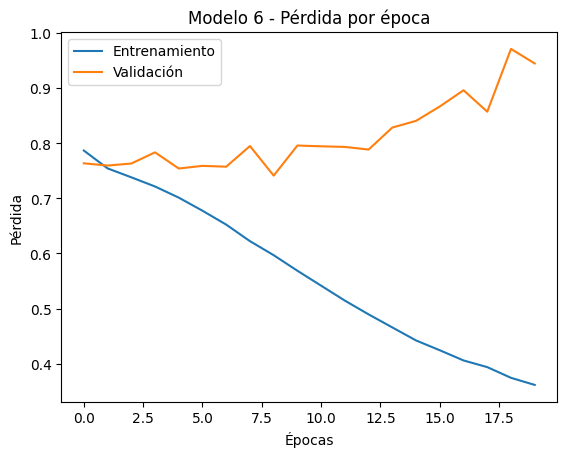

In [ ]:
with mlflow.start_run(run_name='Modelo6'):
    model6 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),   # Capa de entrada
        layers.Dense(128, activation='relu'),   # Primera capa oculta (128)
        layers.Dense(64, activation='relu'),    # Segunda capa oculta (64)
        layers.Dense(64, activation='relu'),    # Tercera capa oculta (64)
        layers.Dense(32, activation='relu'),    # Cuarta capa oculta (32)
        layers.Dense(32, activation='relu'),    # Quinta capa oculta (32)
        layers.Dense(3, activation='softmax')   # Capa de salida (3 clases)
    ])

    model6.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history6 = model6.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss6, test_acc6 = model6.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc6)
    mlflow.log_metric('test_loss', test_loss6)

    # Obtener predicciones del Modelo 6
    predicciones_prob = model6.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    # Calcular MSE y R² del Modelo 6
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    print(f"Modelo 6 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    plt.plot(history6.history['loss'], label='Entrenamiento')
    plt.plot(history6.history['val_loss'], label='Validación')
    plt.title('Modelo 6 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()



### Modelo 7: 3 Capas y 256 neuronas en la primera capa, 128 neuronas en cada capa con 3 salidas 

2025/05/25 19:14:45 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'pandas.core.frame.DataFrame'>. Dataset logging skipped.
2025/05/25 19:14:45 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'DataFrame' object has no attribute 'flatten'


Epoch 1/20
637/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6195 - loss: 0.8022

644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6197 - loss: 0.8019 - val_accuracy: 0.6486 - val_loss: 0.7609
Epoch 2/20
635/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6533 - loss: 0.7440

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6533 - loss: 0.7441 - val_accuracy: 0.6484 - val_loss: 0.7516
Epoch 3/20
630/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6646 - loss: 0.7239

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6645 - loss: 0.7240 - val_accuracy: 0.6535 - val_loss: 0.7458
Epoch 4/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6790 - loss: 0.6946 - val_accuracy: 0.6587 - val_loss: 0.7523
Epoch 5/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6966 - loss: 0.6640 - val_accuracy: 0.6556 - val_loss: 0.7540
Epoch 6/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7166 - loss: 0.6226

644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7166 - loss: 0.6226 - val_accuracy: 0.6702 - val_loss: 0.7425
Epoch 7/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7428 - loss: 0.5787 - val_accuracy: 0.6830 - val_loss: 0.7521
Epoch 8/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7661 - loss: 0.5301 - val_accuracy: 0.6886 - val_loss: 0.7775
Epoch 9/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7870 - loss: 0.4875 - val_accuracy: 0.6890 - val_loss: 0.7900
Epoch 10/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8057 - loss: 0.4468 - val_accuracy: 0.7032 - val_loss: 0.8303
Epoch 11/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8312 - loss: 0.3951 - val_accuracy: 0.7032 - val_loss: 0.8788
Epoch 12/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8389 - loss: 0.3822 - val_accuracy: 0.7298 - val_loss: 0.9273
Epoch 13/20
644/644 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8644 - loss: 0.3274 - val_accuracy: 0.7276 - 

2025/05/25 19:15:36 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'pandas.core.frame.DataFrame'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2025/05/25 19:15:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/05/25 19:15:46 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7407 - loss: 1.2297


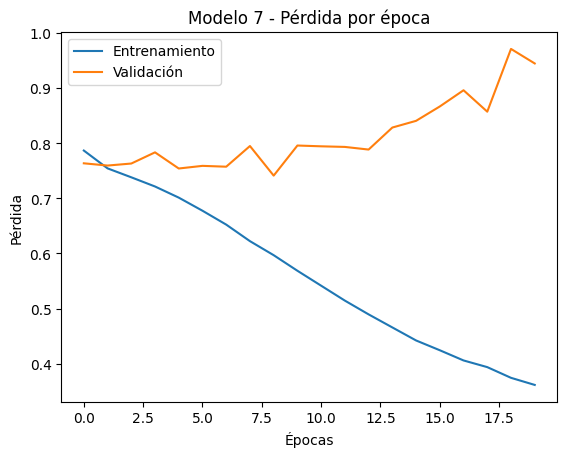

In [ ]:
with mlflow.start_run(run_name='Modelo7'):
    model7 = keras.Sequential([
        keras.Input(shape=(train.shape[1],)),   # Capa de entrada
        layers.Dense(256, activation='relu'),   # Primera capa oculta (128)
        layers.Dense(128, activation='relu'),    # Segunda capa oculta (64)
        layers.Dense(128, activation='relu'),    # Tercera capa oculta (64)
        layers.Dense(3, activation='softmax')   # Capa de salida (3 clases)
    ])

    model7.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history7 = model7.fit(
        train, y_train,
        validation_data=(val, y_val),
        epochs=20,
        batch_size=32
    )

    test_loss7, test_acc7 = model7.evaluate(test, y_test)
    mlflow.log_metric('test_accuracy', test_acc7)
    mlflow.log_metric('test_loss', test_loss7)

    # Obtener predicciones del Modelo 7
    predicciones_prob = model2.predict(test)
    predicciones = np.argmax(predicciones_prob, axis=1)

    print(f"Modelo 7 - Accuracy: {test_acc1:.4f}, Loss: {test_loss1:.4f}, MSE: {mse:.4f}, R²: {r2:.4f}")

    # Calcular MSE y R² del Modelo 7
    mse = mean_squared_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)

    plt.plot(history6.history['loss'], label='Entrenamiento')
    plt.plot(history6.history['val_loss'], label='Validación')
    plt.title('Modelo 7 - Pérdida por época')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    plt.show()

### Comparación de modelos 

In [19]:
# Guardamos métricas manualmente (estos valores son solo ejemplos, pon los tuyos reales)
resultados_modelos = {
    'Modelo5': {'accuracy': test_acc1, 'loss': test_loss1, 'modelo': model1},
    'Modelo6': {'accuracy': test_acc2, 'loss': test_loss2, 'modelo': model2},
    'Modelo7': {'accuracy': test_acc3, 'loss': test_loss3, 'modelo': model3},
    'Modelo7': {'accuracy': test_acc4, 'loss': test_loss4, 'modelo': model4},
    'Modelo5': {'accuracy': test_acc5, 'loss': test_loss5, 'modelo': model5},
    'Modelo6': {'accuracy': test_acc6, 'loss': test_loss6, 'modelo': model6},
    'Modelo7': {'accuracy': test_acc7, 'loss': test_loss7, 'modelo': model7},
    # Agrega aquí todos los modelos que tengas
}

# Encontrar el modelo con mayor accuracy
mejor_modelo_nombre = max(resultados_modelos, key=lambda k: resultados_modelos[k]['accuracy'])
mejor_modelo = resultados_modelos[mejor_modelo_nombre]['modelo']
mejor_accuracy = resultados_modelos[mejor_modelo_nombre]['accuracy']
mejor_loss = resultados_modelos[mejor_modelo_nombre]['loss']

print(f"El mejor modelo es {mejor_modelo_nombre} con accuracy: {mejor_accuracy:.4f} y loss: {mejor_loss:.4f}")


El mejor modelo es Modelo7 con accuracy: 0.7412 y loss: 1.2279


## Mejor modelo

In [20]:
model7.save("modelo_clasificacion.keras")